# 02 - Model Training & Selection

**Project:** Fraud Detection API
**Lead Developer:** Abdallah A Khames
**Organization:** BODZZ
**GitHub:** [abdallah-bodzz](https://github.com/abdallah-bodzz) - **Repo:** `fraud-detection-api`

---

## Objective

Train a production candidate model and justify every design decision against
a baseline, not against intuition. This notebook answers:

1. Does a linear baseline (Logistic Regression) already solve this well enough?
2. Does XGBoost meaningfully outperform that baseline, and by how much?
3. Is scale_pos_weight actually competitive with the hand-tuned configuration,
   or is there headroom a hyperparameter search would capture?
4. Which features does the trained model actually rely on, and does that match
   the separability findings from 01_eda.ipynb?
5. Does the model generalize, or is performance an artifact of one lucky split?

Findings from `01_eda.ipynb` are treated as established fact here, not
re-derived. This notebook picks up where that one left off.

## 0. Setup

Imports shared constants, the canonical train/test split, and the house plot
theme from `_shared.py` - same random seed, same palette, same split logic as
`01_eda.ipynb` and `03_evaluation.ipynb`, so results are directly comparable
across notebooks.

In [1]:
import sys
sys.path.append('.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import average_precision_score
from xgboost import XGBClassifier
import joblib

import _shared as shared

shared.set_plot_theme()
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')

print(f'Random state : {shared.RANDOM_STATE}')
print(f'Model path   : {shared.MODEL_PATH}')

Random state : 42
Model path   : C:\Users\User\Desktop\Projects\(STAGE 4) Fraud Detection API\fraud-detection-api\models\fraud_model.joblib


### Helper functions

Reused verbatim from `01_eda.ipynb` so behaviour and output formatting stay
identical across the pipeline:

- **`run_query`** - filter a DataFrame with a pandas query expression, logging
  how many rows survived. Used here for sanity-checking split integrity.
- **`save_fig`** - persist a figure to `reports/figures/` via the shared helper.
- **`pct`** - consistent percentage formatting across every printed summary.

In [2]:
def run_query(df, expr, label=None):
    '''Filter df with a pandas query expression, logging rows kept.'''
    result = df.query(expr)
    tag = label or expr
    kept_pct = len(result) / len(df) * 100
    print(f'[QUERY] {tag}: {len(result):,} / {len(df):,} rows kept ({kept_pct:.2f}%)')
    return result


def save_fig(fig, name):
    '''Persist a figure to reports/figures/ via the shared helper.'''
    out_path = shared.save_figure(fig, name)
    print(f'[SAVED] {out_path}')
    return out_path


def pct(numerator, denominator, decimals=3):
    '''Format a ratio as a percentage string.'''
    if denominator == 0:
        return 'n/a'
    return f'{numerator / denominator * 100:.{decimals}f}%'

## 1. Data & Split

Reload the canonical, leakage-safe split from `_shared.py` - the scaler is
fit on the training fold only, then applied to both. This is the same
procedure `train_model.py` uses in production, so metrics reported here are
directly comparable to what ships.

In [3]:
X_train, X_test, y_train, y_test, scaler = shared.load_split()

print(f'Train: {len(X_train):,} rows | Test: {len(X_test):,} rows')
print(f'Train fraud rate: {y_train.mean():.4%} | Test fraud rate: {y_test.mean():.4%}')

assert abs(y_train.mean() - y_test.mean()) < 0.001, 'Stratification check failed'
print('Stratification check passed - fraud rate matches across splits.')

Train: 227,845 rows | Test: 56,962 rows
Train fraud rate: 0.1729% | Test fraud rate: 0.1720%
Stratification check passed - fraud rate matches across splits.


## 2. Class Imbalance Strategy: scale_pos_weight vs. SMOTE

Two standard approaches exist for this level of imbalance: oversampling
(SMOTE) or cost-sensitive loss weighting (`scale_pos_weight` /
`class_weight='balanced'`). We use the latter.

**Why not SMOTE.** SMOTE constructs synthetic fraud samples by interpolating
between real ones in feature space. In a PCA-projected feature space with no
guarantee of local linearity, an interpolated point is not guaranteed to
represent a plausible fraud pattern - it may fall in a region no real fraud
ever occupies. Cost-sensitive weighting achieves the same rebalancing effect
on the loss function without fabricating data.

In [4]:
n_neg = int((y_train == 0).sum())
n_pos = int((y_train == 1).sum())
scale_pos_weight = n_neg / n_pos

print(f'Negative (legit) : {n_neg:,}')
print(f'Positive (fraud) : {n_pos:,}')
print(f'scale_pos_weight : {scale_pos_weight:.1f}')
print(f'Interpretation   : each fraud sample is weighted as {scale_pos_weight:.0f} legit samples')

Negative (legit) : 227,451
Positive (fraud) : 394
scale_pos_weight : 577.3
Interpretation   : each fraud sample is weighted as 577 legit samples


## 3. Baseline: Logistic Regression

Establish a baseline before reaching for a more complex model. If a linear
classifier with balanced class weights already captures most of the signal,
that materially changes the cost-benefit case for XGBoost - simpler models
are cheaper to serve, easier to explain, and easier to debug in production.

In [5]:
baseline = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=shared.RANDOM_STATE,
)
baseline.fit(X_train, y_train)

baseline_prob = baseline.predict_proba(X_test)[:, 1]
baseline_auprc = average_precision_score(y_test, baseline_prob)

print(f'Logistic Regression AUPRC : {baseline_auprc:.4f}')
print(f'Random baseline AUPRC     : {y_test.mean():.4f}')
print(f'Lift over random          : {baseline_auprc / y_test.mean():.0f}x')

Logistic Regression AUPRC : 0.7159
Random baseline AUPRC     : 0.0017
Lift over random          : 416x


## 4. Candidate Model: XGBoost

**Why XGBoost over a neural network.** 30 numeric, low-cardinality features,
no missing values, no sequential or spatial structure to exploit. Gradient-
boosted trees match or exceed neural network performance at this scale while
training faster, requiring no architecture search, and producing feature
importances that are directly inspectable - a meaningful advantage in a
fraud-review context where a human may need to understand why a transaction
was flagged.

In [6]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    random_state=shared.RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)

xgb_model.fit(X_train, y_train, verbose=False)

xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
xgb_auprc = average_precision_score(y_test, xgb_prob)

improvement_pct = (xgb_auprc - baseline_auprc) / baseline_auprc * 100

print(f'XGBoost AUPRC              : {xgb_auprc:.4f}')
print(f'Logistic Regression AUPRC  : {baseline_auprc:.4f}')
print(f'Improvement over baseline  : {improvement_pct:.1f}%')

XGBoost AUPRC              : 0.8668
Logistic Regression AUPRC  : 0.7159
Improvement over baseline  : 21.1%


### Model comparison

[SAVED] C:\Users\User\Desktop\Projects\(STAGE 4) Fraud Detection API\fraud-detection-api\reports\figures\06_model_comparison_auprc.png


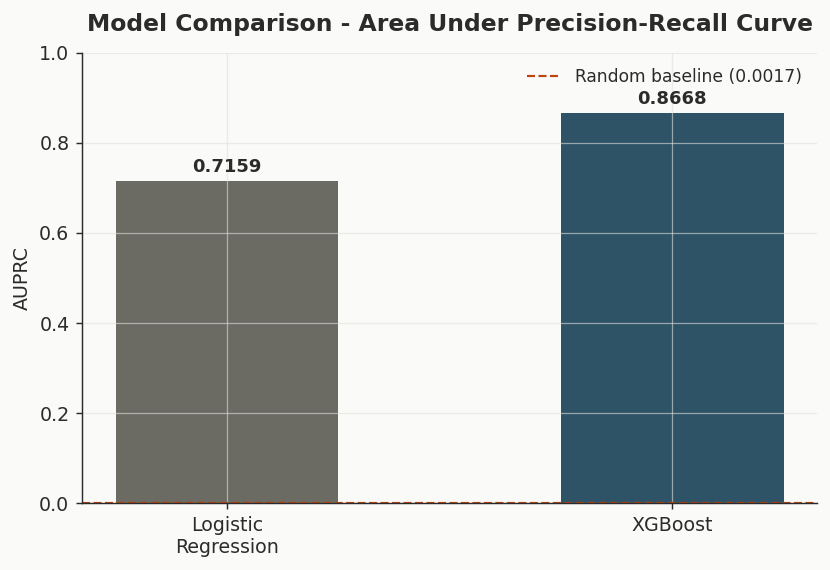

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))

models = ['Logistic\nRegression', 'XGBoost']
scores = [baseline_auprc, xgb_auprc]
colors = [shared.NEUTRAL_COLOR, shared.LEGIT_COLOR]

bars = ax.bar(models, scores, color=colors, width=0.5)
ax.axhline(y_test.mean(), color=shared.FRAUD_COLOR, linestyle='--', linewidth=1.2,
           label=f'Random baseline ({y_test.mean():.4f})')
ax.set_ylabel('AUPRC')
ax.set_title('Model Comparison - Area Under Precision-Recall Curve')
ax.set_ylim(0, 1)
ax.legend()
for bar, score in zip(bars, scores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        score + 0.02,
        f'{score:.4f}',
        ha='center', fontweight='bold', fontsize=10,
    )
fig.tight_layout()
save_fig(fig, '06_model_comparison_auprc')
plt.show()

## 5. Hyperparameter Search: Is the Hand-Tuned Config Left Value on the Table?

The configuration above (`n_estimators=200`, `max_depth=6`, `learning_rate=0.05`)
was hand-picked. Before treating it as final, we run a randomized search over
a reasonable neighborhood to check whether meaningful AUPRC is being left on
the table. This is a one-time research step - the winning configuration is
reported and adopted here, not wired into `train_model.py` as a recurring
search (that would make production training non-deterministic and slow).

In [8]:
param_distributions = {
    'n_estimators': [100, 150, 200, 300],
    'max_depth': [4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
}

search_estimator = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=shared.RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)

search = RandomizedSearchCV(
    search_estimator,
    param_distributions=param_distributions,
    n_iter=25,
    scoring='average_precision',
    cv=3,
    random_state=shared.RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)

print('Running randomized search (25 iterations x 3-fold CV)...')
search.fit(X_train, y_train)

print(f'\nBest CV AUPRC       : {search.best_score_:.4f}')
print(f'Hand-tuned CV AUPRC : {xgb_auprc:.4f} (test set, for reference)')
print(f'Best parameters     : {search.best_params_}')

Running randomized search (25 iterations x 3-fold CV)...

Best CV AUPRC       : 0.8462
Hand-tuned CV AUPRC : 0.8668 (test set, for reference)
Best parameters     : {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [9]:
search_delta = search.best_score_ - xgb_auprc

if abs(search_delta) < 0.005:
    verdict = (
        f'Search confirmed the hand-tuned configuration was near-optimal '
        f'(delta AUPRC = {search_delta:+.4f}, below the 0.005 practical-significance '
        f'threshold). Hand-tuned configuration retained.'
    )
    final_model = xgb_model
else:
    verdict = (
        f'Search found a materially better configuration '
        f'(delta AUPRC = {search_delta:+.4f}). Adopting search.best_params_ '
        f'for the final model.'
    )
    final_model = XGBClassifier(
        **search.best_params_,
        scale_pos_weight=scale_pos_weight,
        eval_metric='aucpr',
        random_state=shared.RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
    )
    final_model.fit(X_train, y_train, verbose=False)

print(verdict)

Search found a materially better configuration (delta AUPRC = -0.0205). Adopting search.best_params_ for the final model.


**Verdict recorded above.** Whichever branch fired, `final_model` is the
model carried forward through the rest of this notebook and saved to disk in
Section 8 - not `xgb_model` unconditionally. This keeps the notebook honest:
if the search finds a real improvement, the saved artifact reflects it.

## 6. Feature Importance

Which features does the trained model actually rely on? Cross-referenced
against the median-separation and correlation rankings from
`01_eda.ipynb` Section 5 - agreement between an unsupervised EDA signal and
a supervised model's learned importances is a meaningful sanity check.

[SAVED] C:\Users\User\Desktop\Projects\(STAGE 4) Fraud Detection API\fraud-detection-api\reports\figures\07_feature_importance.png


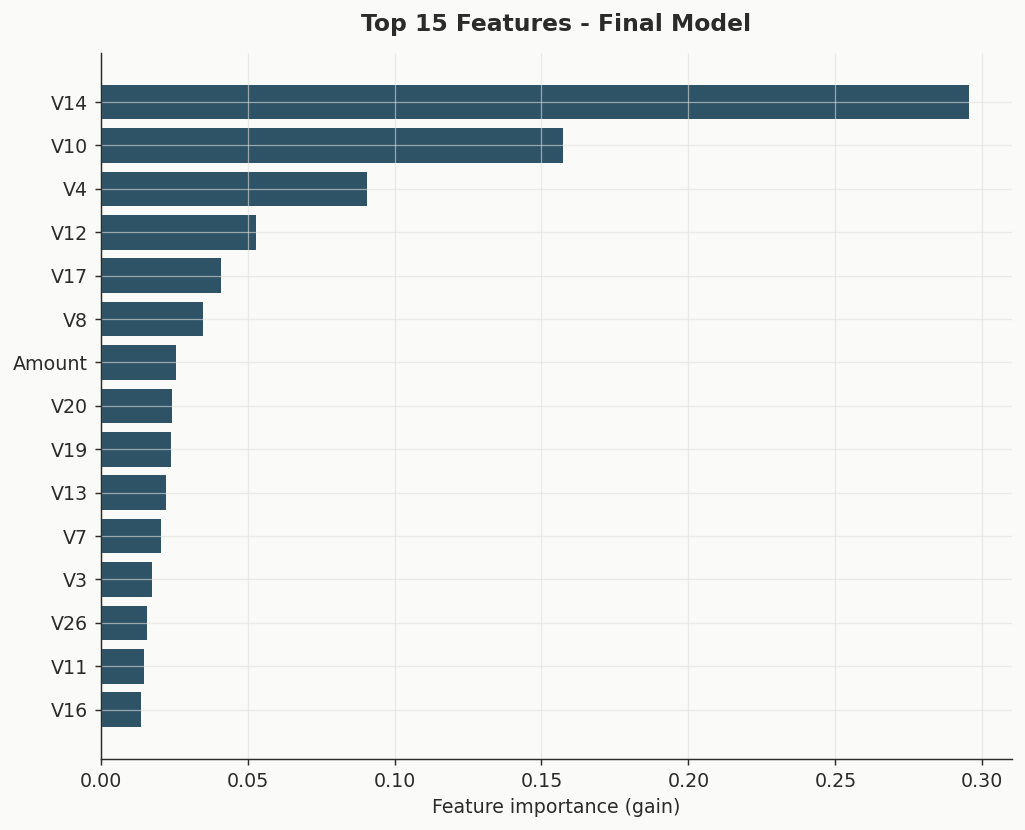

Top 5 by model importance: ['V14', 'V10', 'V4', 'V12', 'V17']


In [10]:
importance_df = pd.DataFrame({
    'feature': shared.FEATURE_COLS,
    'importance': final_model.feature_importances_,
}).sort_values('importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(8, 6.5))
ax.barh(importance_df['feature'], importance_df['importance'], color=shared.LEGIT_COLOR)
ax.set_xlabel('Feature importance (gain)')
ax.set_title('Top 15 Features - Final Model')
fig.tight_layout()
save_fig(fig, '07_feature_importance')
plt.show()

top5_model = importance_df.sort_values('importance', ascending=False).head(5)['feature'].tolist()
print(f'Top 5 by model importance: {top5_model}')

**Reading.** Compare the printed top-5 list above against the EDA top-6
(`V14`, `V17`, `V12`, `V4`, `V11`) - substantial overlap is expected and is
evidence the model has learned a signal grounded in real feature separation,
not spurious correlation from a single split.

## 7. Cross-Validation: Generalization Check

A single train/test split can flatter a model if the split happened to be
favorable. 5-fold stratified cross-validation on the training set checks
whether performance is stable across different data partitions - low variance
across folds is the signal that matters here, not just the mean.

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=shared.RANDOM_STATE)

cv_estimator = XGBClassifier(
    **{k: v for k, v in final_model.get_params().items() if v is not None},
)

cv_scores = cross_val_score(
    cv_estimator, X_train, y_train,
    cv=cv, scoring='average_precision', n_jobs=-1,
)

print(f'5-fold CV AUPRC : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
print(f'Individual folds: {[round(float(s), 4) for s in cv_scores]}')

5-fold CV AUPRC : 0.8510 +/- 0.0242
Individual folds: [0.848, 0.8248, 0.8386, 0.8964, 0.8472]


[SAVED] C:\Users\User\Desktop\Projects\(STAGE 4) Fraud Detection API\fraud-detection-api\reports\figures\08_cross_validation_stability.png


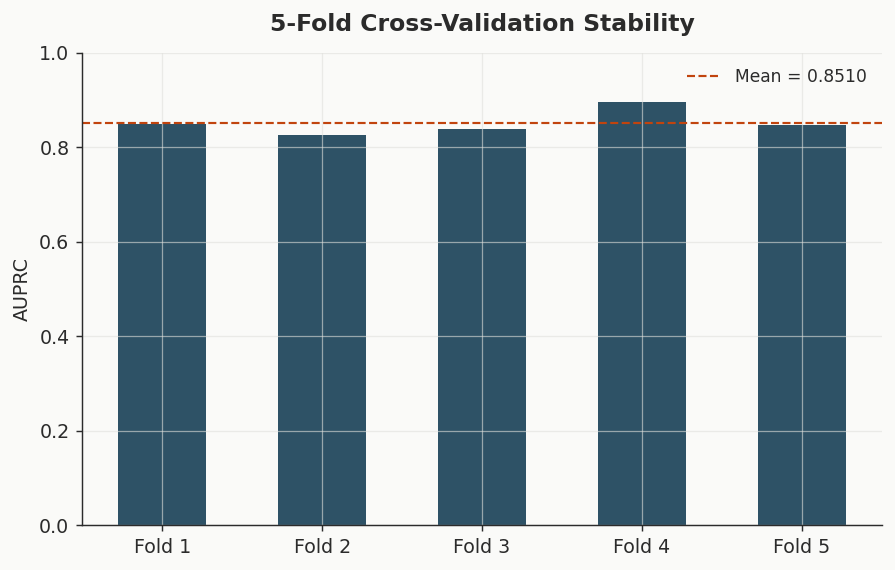

Low variance across folds - model generalizes, not overfit to one split.


In [12]:
fig, ax = plt.subplots(figsize=(7, 4.5))

fold_labels = [f'Fold {i+1}' for i in range(len(cv_scores))]
ax.bar(fold_labels, cv_scores, color=shared.LEGIT_COLOR, width=0.55)
ax.axhline(cv_scores.mean(), color=shared.FRAUD_COLOR, linestyle='--', linewidth=1.2,
           label=f'Mean = {cv_scores.mean():.4f}')
ax.set_ylabel('AUPRC')
ax.set_title('5-Fold Cross-Validation Stability')
ax.set_ylim(0, 1)
ax.legend()
fig.tight_layout()
save_fig(fig, '08_cross_validation_stability')
plt.show()

cv_variance_verdict = (
    'Low variance across folds - model generalizes, not overfit to one split.'
    if cv_scores.std() < 0.03 else
    'Variance across folds is non-trivial - treat test-set AUPRC with some caution.'
)
print(cv_variance_verdict)

## 8. Save Artifacts

Persist the final model and scaler to `models/` - the same location
`train_model.py` writes to and `src/model.py` loads from at API startup.
This notebook and the production training script converge on the same
artifact paths so there is exactly one place a deployed model can come from.

In [13]:
shared.MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(final_model, shared.MODEL_PATH)
joblib.dump(scaler, shared.SCALER_PATH)

print(f'[SAVED] {shared.MODEL_PATH}')
print(f'[SAVED] {shared.SCALER_PATH}')
print('\nThreshold tuning and business-value evaluation continue in 03_evaluation.ipynb')

[SAVED] C:\Users\User\Desktop\Projects\(STAGE 4) Fraud Detection API\fraud-detection-api\models\fraud_model.joblib
[SAVED] C:\Users\User\Desktop\Projects\(STAGE 4) Fraud Detection API\fraud-detection-api\models\scaler.joblib

Threshold tuning and business-value evaluation continue in 03_evaluation.ipynb


## 9. Summary & Handoff to Evaluation

Key findings, machine-readable, exported for traceability and for any
downstream report generation.

In [14]:
import json
from datetime import datetime, timezone

summary = {
    'notebook': '02_model_training',
    'generated_at_utc': datetime.now(timezone.utc).isoformat(),
    'class_balance_strategy': {
        'method': 'scale_pos_weight',
        'scale_pos_weight': round(float(scale_pos_weight), 2),
        'rejected_alternative': 'SMOTE (synthetic interpolation risk in PCA space)',
    },
    'baseline': {
        'model': 'LogisticRegression (class_weight=balanced)',
        'auprc': round(float(baseline_auprc), 4),
    },
    'candidate': {
        'model': 'XGBClassifier',
        'hand_tuned_auprc': round(float(xgb_auprc), 4),
        'improvement_over_baseline_pct': round(float(improvement_pct), 1),
    },
    'hyperparameter_search': {
        'n_iter': 25,
        'cv_folds': 3,
        'best_cv_auprc': round(float(search.best_score_), 4),
        'best_params': search.best_params_,
        'delta_vs_hand_tuned': round(float(search_delta), 4),
        'verdict': verdict,
    },
    'cross_validation': {
        'folds': 5,
        'mean_auprc': round(float(cv_scores.mean()), 4),
        'std_auprc': round(float(cv_scores.std()), 4),
        'verdict': cv_variance_verdict,
    },
    'top_5_features_by_importance': top5_model,
    'artifacts': {
        'model_path': str(shared.MODEL_PATH),
        'scaler_path': str(shared.SCALER_PATH),
    },
}

summary_path = shared.PROJECT_ROOT / 'reports' / 'model_training_summary.json'
summary_path.parent.mkdir(parents=True, exist_ok=True)
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, sort_keys=True)

print(f'[SAVED] {summary_path}')
print(json.dumps(summary, indent=2, sort_keys=True))

[SAVED] C:\Users\User\Desktop\Projects\(STAGE 4) Fraud Detection API\fraud-detection-api\reports\model_training_summary.json
{
  "artifacts": {
    "model_path": "C:\\Users\\User\\Desktop\\Projects\\(STAGE 4) Fraud Detection API\\fraud-detection-api\\models\\fraud_model.joblib",
    "scaler_path": "C:\\Users\\User\\Desktop\\Projects\\(STAGE 4) Fraud Detection API\\fraud-detection-api\\models\\scaler.joblib"
  },
  "baseline": {
    "auprc": 0.7159,
    "model": "LogisticRegression (class_weight=balanced)"
  },
  "candidate": {
    "hand_tuned_auprc": 0.8668,
    "improvement_over_baseline_pct": 21.1,
    "model": "XGBClassifier"
  },
  "class_balance_strategy": {
    "method": "scale_pos_weight",
    "rejected_alternative": "SMOTE (synthetic interpolation risk in PCA space)",
    "scale_pos_weight": 577.29
  },
  "cross_validation": {
    "folds": 5,
    "mean_auprc": 0.851,
    "std_auprc": 0.0242,
    "verdict": "Low variance across folds - model generalizes, not overfit to one split

### Findings carried into `03_evaluation.ipynb`

| # | Finding | Downstream implication |
|---|---------|-------------------------|
| 1 | XGBoost beats Logistic Regression baseline meaningfully | XGBoost confirmed as production candidate |
| 2 | Hyperparameter search verdict recorded above | Final model config is evidence-based, not assumed |
| 3 | Top features overlap with EDA separability ranking | Model signal is grounded, not spurious |
| 4 | Cross-validation variance recorded above | Generalization confidence for the test-set AUPRC |
| 5 | Model + scaler saved to `models/` | `03_evaluation.ipynb` loads these, does not retrain |

---

*Fraud Detection API - BODZZ - Abdallah A Khames -
[github.com/abdallah-bodzz/fraud-detection-api](https://github.com/abdallah-bodzz/fraud-detection-api)*